<a href="https://colab.research.google.com/github/aryaveermajumdar/fsfm-based-neutral-face-project/blob/main/Neutral_Face_FSFM_Model_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# ============================================================
# MASTER SETUP — Demographic Pipeline Notebook
# ============================================================
import os, sys, torch
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from google.colab import drive

drive.mount('/content/drive')

# GPU check
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Paths
DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks'
DEMO_CACHE = f'{DRIVE_BASE}/demographic_classifier'
os.makedirs(DEMO_CACHE, exist_ok=True)

# FSFM transform
MEAN = [0.5482207536697388, 0.42340534925460815, 0.3654651641845703]
STD  = [0.2789176106452942, 0.2438540756702423,  0.23493893444538116]
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA: True
GPU: Tesla T4
Setup complete.


In [25]:
# # Cell — Clone repo + install deps
# !git clone https://github.com/wolo-wolo/FSFM-CVPR25.git
# !pip install timm einops huggingface_hub --quiet

In [26]:
# # Cell — Download checkpoint
# from huggingface_hub import hf_hub_download
# import os

# os.makedirs('/content/fsfm_checkpoints', exist_ok=True)

# hf_hub_download(
#     repo_id="Wolowolo/fsfm-3c",
#     filename="pretrained_models/VF2_ViT-B/checkpoint-400.pth",
#     local_dir="/content/fsfm_checkpoints/",
#     local_dir_use_symlinks=False,
#     resume_download=True
# )
# print("Checkpoint ready.")

In [27]:
# # Cell — Load backbone
# import sys, torch

# sys.path.insert(0, '/content/FSFM-CVPR25/fsfm-3c/finuetune/cross_domain_FAS')
# import models_vit

# backbone = models_vit.vit_base_patch16(
#     num_classes=0, drop_path_rate=0.0, global_pool=False
# )
# checkpoint = torch.load(
#     '/content/fsfm_checkpoints/pretrained_models/VF2_ViT-B/checkpoint-400.pth',
#     map_location='cpu', weights_only=False
# )
# backbone.load_state_dict(checkpoint['model'], strict=False)
# backbone = backbone.cuda().eval()
# print("Backbone ready.")

# # Sanity check
# dummy = torch.randn(2, 3, 224, 224).cuda()
# with torch.no_grad():
#     out = backbone.forward_features(dummy)[:, 0, :]
# print("CLS token shape:", out.shape)  # should be (2, 768)

In [28]:
# import torch
# from torch.utils.data import DataLoader, Dataset
# from PIL import Image
# import numpy as np

# class FairFaceDataset(Dataset):
#     def __init__(self, hf_split, transform):
#         self.data = hf_split
#         self.transform = transform

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         image  = sample['image'].convert('RGB')
#         image  = self.transform(image)
#         race   = sample['race']
#         gender = sample['gender']
#         age    = sample['age']
#         return image, race, gender, age

# train_ds_ff = FairFaceDataset(fairface['train'],      transform)
# val_ds_ff   = FairFaceDataset(fairface['validation'], transform)

# print(f"Train: {len(train_ds_ff)} | Val: {len(val_ds_ff)}")

# # --- Extract and cache features ---
# def extract_features(dataset, backbone, cache_path, batch_size=128):
#     if os.path.exists(cache_path):
#         print(f"Cache found, loading: {cache_path}")
#         return torch.load(cache_path, weights_only=False)

#     loader = DataLoader(dataset, batch_size=batch_size,
#                         shuffle=False, num_workers=2)
#     all_feats, all_races, all_genders, all_ages = [], [], [], []

#     backbone.eval()
#     with torch.no_grad():
#         for i, (imgs, races, genders, ages) in enumerate(loader):
#             imgs  = imgs.cuda()
#             feats = backbone.forward_features(imgs)[:, 0, :].cpu()
#             all_feats.append(feats)
#             all_races.append(races)
#             all_genders.append(genders)
#             all_ages.append(ages)
#             if i % 50 == 0:
#                 print(f"  Batch {i}/{len(loader)}")

#     cache = {
#         'features': torch.cat(all_feats),
#         'races':    torch.cat(all_races),
#         'genders':  torch.cat(all_genders),
#         'ages':     torch.cat(all_ages),
#     }
#     torch.save(cache, cache_path)
#     print(f"Saved to {cache_path}")
#     return cache

# print("\nExtracting train features...")
# train_ff_cache = extract_features(
#     train_ds_ff, backbone,
#     f'{DEMO_CACHE}/fairface_train_features.pt'
# )

# print("\nExtracting val features...")
# val_ff_cache = extract_features(
#     val_ds_ff, backbone,
#     f'{DEMO_CACHE}/fairface_val_features.pt'
# )

# print(f"\nTrain features: {train_ff_cache['features'].shape}")
# print(f"Val features:   {val_ff_cache['features'].shape}")

In [29]:
# import torch
# import os

# RACE_NAMES_4 = {
#     0: 'White/Middle Eastern',
#     1: 'Black',
#     2: 'Asian',
#     3: 'Indian/Latino'
# }

# FAIRFACE_TO_4CLASS = {
#     3: 0,  # White          → White/Middle Eastern
#     4: 0,  # Middle Eastern → White/Middle Eastern
#     2: 1,  # Black          → Black
#     0: 2,  # East Asian     → Asian
#     6: 2,  # SE Asian       → Asian
#     1: 3,  # Indian         → Indian/Latino
#     5: 3,  # Latino         → Indian/Latino
# }

# # --- Remap FairFace caches ---
# def remap_races(cache, mapping):
#     new_cache = dict(cache)
#     old_races = cache['races']
#     new_races = torch.tensor(
#         [mapping[r.item()] for r in old_races],
#         dtype=torch.long
#     )
#     new_cache['races'] = new_races
#     return new_cache

# train_ff_4 = remap_races(train_ff_cache, FAIRFACE_TO_4CLASS)
# val_ff_4   = remap_races(val_ff_cache,   FAIRFACE_TO_4CLASS)

# # Save remapped caches
# torch.save(train_ff_4, f'{DEMO_CACHE}/fairface_train_4class.pt')
# torch.save(val_ff_4,   f'{DEMO_CACHE}/fairface_val_4class.pt')

# # Verify distribution
# from collections import Counter
# dist = Counter(train_ff_4['races'].tolist())
# print("FairFace train race distribution (4-class):")
# for rid, count in sorted(dist.items()):
#     print(f"  {RACE_NAMES_4[rid]}: {count}")

# # --- Remap RAF-DB caches ---
# RAFDB_TO_4CLASS = {
#     0: 0,  # Caucasian        → White/Middle Eastern
#     1: 1,  # Black            → Black
#     2: 2,  # Asian            → Asian
# }

# RAFDB_BASE_CACHE = '/content/drive/MyDrive/Colab Notebooks/RAF-DB'

# train_raf = torch.load(f'{RAFDB_BASE_CACHE}/train_features.pt', weights_only=False)
# test_raf  = torch.load(f'{RAFDB_BASE_CACHE}/test_features.pt',  weights_only=False)

# train_raf_4 = remap_races(train_raf, RAFDB_TO_4CLASS)
# test_raf_4  = remap_races(test_raf,  RAFDB_TO_4CLASS)

# torch.save(train_raf_4, f'{RAFDB_BASE_CACHE}/train_features_4class.pt')
# torch.save(test_raf_4,  f'{RAFDB_BASE_CACHE}/test_features_4class.pt')

# dist2 = Counter(train_raf_4['races'].tolist())
# print("\nRAF-DB train race distribution (4-class):")
# for rid, count in sorted(dist2.items()):
#     print(f"  {RACE_NAMES_4[rid]}: {count}")

In [30]:
# # FairFace age classes:
# # 0='0-2', 1='3-9', 2='10-19', 3='20-29', 4='30-39',
# # 5='40-49', 6='50-59', 7='60-69', 8='more than 70'

# AGE_TO_3CLASS = {
#     0: 0,  # 0-2    → Young
#     1: 0,  # 3-9    → Young
#     2: 0,  # 10-19  → Young
#     3: 1,  # 20-29  → Middle
#     4: 1,  # 30-39  → Middle
#     5: 1,  # 40-49  → Middle
#     6: 2,  # 50-59  → Old
#     7: 2,  # 60-69  → Old
#     8: 2,  # 70+    → Old
# }

# AGE_NAMES_3 = {0: 'Young', 1: 'Middle', 2: 'Old'}

In [31]:
# def remap_ages(cache, mapping):
#     new_cache = dict(cache)
#     old_ages = cache['ages']
#     new_ages = torch.tensor(
#         [mapping[a.item()] for a in old_ages],
#         dtype=torch.long
#     )
#     new_cache['ages'] = new_ages
#     return new_cache

# train_ff_4 = remap_ages(train_ff_4, AGE_TO_3CLASS)
# val_ff_4   = remap_ages(val_ff_4,   AGE_TO_3CLASS)

# # Check distribution
# from collections import Counter
# dist = Counter(train_ff_4['ages'].tolist())
# print("Age distribution (3-class):")
# for aid, count in sorted(dist.items()):
#     print(f"  {AGE_NAMES_3[aid]}: {count}")

In [32]:
# class DemographicClassifier4v2(nn.Module):
#     def __init__(self, feature_dim=768, hidden_dim=512,
#                  num_races=4, num_genders=2, num_ages=3, dropout=0.3):
#         super().__init__()

#         self.trunk = nn.Sequential(
#             nn.Linear(feature_dim, hidden_dim),
#             nn.LayerNorm(hidden_dim),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim, 256),
#             nn.GELU(),
#             nn.Dropout(dropout),
#         )

#         self.race_head   = nn.Linear(256, num_races)
#         self.gender_head = nn.Linear(256, num_genders)
#         self.age_head    = nn.Linear(256, num_ages)

#     def forward(self, x):
#         shared = self.trunk(x)
#         return (
#             self.race_head(shared),
#             self.gender_head(shared),
#             self.age_head(shared)
#         )


# train_loader = DataLoader(
#     TensorDataset(
#         train_ff_4['features'],
#         train_ff_4['races'],
#         train_ff_4['genders'],
#         train_ff_4['ages']
#     ),
#     batch_size=512, shuffle=True
# )
# val_loader = DataLoader(
#     TensorDataset(
#         val_ff_4['features'],
#         val_ff_4['races'],
#         val_ff_4['genders'],
#         val_ff_4['ages']
#     ),
#     batch_size=512, shuffle=False
# )

# demo_clf4v2 = DemographicClassifier4v2().cuda()
# optimizer   = optim.AdamW(demo_clf4v2.parameters(), lr=1e-3, weight_decay=0.05)
# criterion   = nn.CrossEntropyLoss()

# NUM_EPOCHS = 20
# for epoch in range(NUM_EPOCHS):
#     demo_clf4v2.train()
#     total_loss = 0
#     r_correct = g_correct = a_correct = total = 0

#     for feats, races, genders, ages in train_loader:
#         feats, races, genders, ages = (feats.cuda(), races.cuda(),
#                                        genders.cuda(), ages.cuda())
#         r_logits, g_logits, a_logits = demo_clf4v2(feats)
#         loss = (criterion(r_logits, races) +
#                 criterion(g_logits, genders) +
#                 criterion(a_logits, ages))
#         optimizer.zero_grad(); loss.backward(); optimizer.step()
#         total_loss += loss.item()
#         r_correct  += (r_logits.argmax(1) == races).sum().item()
#         g_correct  += (g_logits.argmax(1) == genders).sum().item()
#         a_correct  += (a_logits.argmax(1) == ages).sum().item()
#         total      += feats.size(0)

#     demo_clf4v2.eval()
#     vr = vg = va = vtotal = 0
#     with torch.no_grad():
#         for feats, races, genders, ages in val_loader:
#             feats, races, genders, ages = (feats.cuda(), races.cuda(),
#                                            genders.cuda(), ages.cuda())
#             r_logits, g_logits, a_logits = demo_clf4v2(feats)
#             vr     += (r_logits.argmax(1) == races).sum().item()
#             vg     += (g_logits.argmax(1) == genders).sum().item()
#             va     += (a_logits.argmax(1) == ages).sum().item()
#             vtotal += feats.size(0)

#     print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
#           f"Loss: {total_loss/len(train_loader):.3f} | "
#           f"Race: {vr/vtotal:.3f} | "
#           f"Gender: {vg/vtotal:.3f} | "
#           f"Age: {va/vtotal:.3f}")

# torch.save(demo_clf4v2.state_dict(),
#            f'{DEMO_CACHE}/demographic_classifier_4race_3age.pt')
# print("Saved.")

In [33]:
# # Remap RAF-DB age to 3-class
# train_raf_4 = remap_ages(train_raf_4, AGE_TO_3CLASS)
# test_raf_4  = remap_ages(test_raf_4,  AGE_TO_3CLASS)

# # Verify
# dist_age = Counter(train_raf_4['ages'].tolist())
# print("RAF-DB train age distribution (3-class):")
# for aid, count in sorted(dist_age.items()):
#     print(f"  {AGE_NAMES_3[aid]}: {count}")

# # Save updated caches
# torch.save(train_raf_4, f'{RAFDB_BASE_CACHE}/train_features_4race_3age.pt')
# torch.save(test_raf_4,  f'{RAFDB_BASE_CACHE}/test_features_4race_3age.pt')
# print("RAF-DB caches saved.")

In [34]:
# import torch
# import torch.nn.functional as F
# from torch.utils.data import DataLoader
# import os
# from collections import Counter

# CONFIDENCE_THRESHOLD = 0.70

# class AffectNetYOLO(torch.utils.data.Dataset):
#     def __init__(self, split, base_path, transform=None):
#         self.img_dir = os.path.join(base_path, 'YOLO_format', split, 'images')
#         self.lbl_dir = os.path.join(base_path, 'YOLO_format', split, 'labels')
#         self.transform = transform
#         self.samples = []
#         for fname in os.listdir(self.img_dir):
#             if not fname.endswith('.jpg'):
#                 continue
#             lbl_file = os.path.join(self.lbl_dir, fname.replace('.jpg', '.txt'))
#             if not os.path.exists(lbl_file):
#                 continue
#             with open(lbl_file) as f:
#                 line = f.readline().strip()
#             if not line:
#                 continue
#             class_id = int(line.split()[0])
#             self.samples.append((os.path.join(self.img_dir, fname), class_id))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         from PIL import Image
#         img_path, label = self.samples[idx]
#         image = Image.open(img_path).convert('RGB')
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# # Download AffectNet
# import kagglehub
# affectnet_path = kagglehub.dataset_download("fatihkgg/affectnet-yolo-format")

# train_an = AffectNetYOLO('train', affectnet_path, transform)
# val_an   = AffectNetYOLO('valid', affectnet_path, transform)
# print(f"AffectNet train: {len(train_an)} | val: {len(val_an)}")

# # Auto-label
# def autolabel_dataset(dataset, backbone, demo_clf, cache_path,
#                       threshold=0.70, batch_size=128):
#     if os.path.exists(cache_path):
#         print(f"Cache found: {cache_path}")
#         return torch.load(cache_path, weights_only=False)

#     loader = DataLoader(dataset, batch_size=batch_size,
#                         shuffle=False, num_workers=2)
#     all_feats, all_labels = [], []
#     all_races, all_genders, all_ages = [], [], []
#     all_race_conf, all_confident = [], []

#     backbone.eval()
#     demo_clf.eval()

#     with torch.no_grad():
#         for i, (imgs, labels) in enumerate(loader):
#             imgs = imgs.cuda()
#             feats = backbone.forward_features(imgs)[:, 0, :].cpu()

#             r_logits, g_logits, a_logits = demo_clf(feats.cuda())
#             r_probs = F.softmax(r_logits, dim=1).cpu()
#             g_probs = F.softmax(g_logits, dim=1).cpu()
#             a_probs = F.softmax(a_logits, dim=1).cpu()

#             r_conf, r_pred = r_probs.max(dim=1)
#             _,      g_pred = g_probs.max(dim=1)
#             _,      a_pred = a_probs.max(dim=1)

#             confident = r_conf >= threshold

#             all_feats.append(feats)
#             all_labels.append(labels)
#             all_races.append(r_pred)
#             all_genders.append(g_pred)
#             all_ages.append(a_pred)
#             all_race_conf.append(r_conf)
#             all_confident.append(confident)

#             if i % 20 == 0:
#                 print(f"  Batch {i}/{len(loader)}")

#     cache = {
#         'features':  torch.cat(all_feats),
#         'labels':    torch.cat(all_labels),
#         'races':     torch.cat(all_races),
#         'genders':   torch.cat(all_genders),
#         'ages':      torch.cat(all_ages),
#         'race_conf': torch.cat(all_race_conf),
#         'confident': torch.cat(all_confident),
#     }
#     torch.save(cache, cache_path)
#     print(f"Saved: {cache_path}")
#     return cache

# print("\nAuto-labeling AffectNet train...")
# an_train_cache = autolabel_dataset(
#     train_an, backbone, demo_clf4v2,
#     f'{DEMO_CACHE}/affectnet_train_autolabeled.pt'
# )

# print("\nAuto-labeling AffectNet val...")
# an_val_cache = autolabel_dataset(
#     val_an, backbone, demo_clf4v2,
#     f'{DEMO_CACHE}/affectnet_val_autolabeled.pt'
# )

# # Stats
# confident_mask = an_train_cache['confident']
# print(f"\nAffectNet train: {len(confident_mask)} total")
# print(f"  Confident (>{CONFIDENCE_THRESHOLD}): {confident_mask.sum().item()}")
# print(f"  Uncertain: {(~confident_mask).sum().item()}")

# print("\nRace distribution (confident only):")
# conf_races = an_train_cache['races'][confident_mask]
# dist = Counter(conf_races.tolist())
# for rid, count in sorted(dist.items()):
#     print(f"  {RACE_NAMES_4[rid]}: {count}")

# print("\nEmotion distribution (confident only):")
# AFFECTNET_CLASSES = ['Anger','Contempt','Disgust','Fear',
#                      'Happy','Neutral','Sad','Surprise']
# conf_labels = an_train_cache['labels'][confident_mask]
# dist2 = Counter(conf_labels.tolist())
# for cid, count in sorted(dist2.items()):
#     print(f"  {AFFECTNET_CLASSES[cid]}: {count}")

In [35]:
# import torch
# from collections import Counter

# # AffectNet label mapping to RAF-DB 7-class schema
# # AffectNet: 0=Anger, 1=Contempt, 2=Disgust, 3=Fear,
# #            4=Happy, 5=Neutral, 6=Sad, 7=Surprise
# # RAF-DB:    0=Surprise, 1=Fear, 2=Disgust, 3=Happiness,
# #            4=Sadness, 5=Anger, 6=Neutral

# AFFECTNET_TO_RAFDB = {
#     0: 5,  # Anger    → Anger
#     1: 2,  # Contempt → Disgust (merge)
#     2: 2,  # Disgust  → Disgust
#     3: 1,  # Fear     → Fear
#     4: 3,  # Happy    → Happiness
#     5: 6,  # Neutral  → Neutral
#     6: 4,  # Sad      → Sadness
#     7: 0,  # Surprise → Surprise
# }

# UNIFIED_CLASSES = ['Surprise', 'Fear', 'Disgust',
#                    'Happiness', 'Sadness', 'Anger', 'Neutral']

# # Get confident AffectNet samples only
# conf_mask = an_train_cache['confident']
# an_feats   = an_train_cache['features'][conf_mask]
# an_races   = an_train_cache['races'][conf_mask]
# an_genders = an_train_cache['genders'][conf_mask]
# an_ages    = an_train_cache['ages'][conf_mask]

# # Remap AffectNet labels to RAF-DB schema
# an_raw_labels = an_train_cache['labels'][conf_mask]
# an_labels = torch.tensor(
#     [AFFECTNET_TO_RAFDB[l.item()] for l in an_raw_labels],
#     dtype=torch.long
# )

# # Also remap AffectNet age to 3-class
# an_ages = torch.tensor(
#     [AGE_TO_3CLASS[a.item()] for a in an_ages],
#     dtype=torch.long
# )

# # Load RAF-DB 4race/3age cache
# train_raf = torch.load(
#     f'{RAFDB_BASE_CACHE}/train_features_4race_3age.pt',
#     weights_only=False
# )

# # Concatenate
# unified_train = {
#     'features': torch.cat([train_raf['features'], an_feats]),
#     'labels':   torch.cat([train_raf['labels'],   an_labels]),
#     'races':    torch.cat([train_raf['races'],     an_races]),
#     'genders':  torch.cat([train_raf['genders'],   an_genders]),
#     'ages':     torch.cat([train_raf['ages'],       an_ages]),
# }

# # Save
# UNIFIED_CACHE = f'{DEMO_CACHE}/unified_train.pt'
# torch.save(unified_train, UNIFIED_CACHE)
# print(f"Unified train: {len(unified_train['features'])} samples")

# # Distribution report
# print("\nEmotion distribution:")
# dist = Counter(unified_train['labels'].tolist())
# for cid, count in sorted(dist.items()):
#     print(f"  {UNIFIED_CLASSES[cid]}: {count}")

# print("\nRace distribution:")
# dist2 = Counter(unified_train['races'].tolist())
# for rid, count in sorted(dist2.items()):
#     print(f"  {RACE_NAMES_4[rid]}: {count}")

# print("\nAge distribution:")
# dist3 = Counter(unified_train['ages'].tolist())
# for aid, count in sorted(dist3.items()):
#     print(f"  {AGE_NAMES_3[aid]}: {count}")

In [36]:
# import random
# import matplotlib.pyplot as plt
# import torch
# import torch.nn.functional as F
# from PIL import Image

# UNIFIED_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
# RACE_NAMES_4    = {0: 'White/Middle Eastern', 1: 'Black', 2: 'Asian', 3: 'Indian/Latino'}
# AGE_NAMES_3     = {0: 'Young', 1: 'Middle', 2: 'Old'}
# GENDER_NAMES    = {0: 'Male', 1: 'Female'}

# # Pick 6 random indices from AffectNet train
# indices = random.sample(range(len(train_an)), 6)

# fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# axes = axes.flatten()

# backbone.eval()
# demo_clf4v2.eval()

# for i, idx in enumerate(indices):
#     img, true_label = train_an[idx]

#     # Show original image (un-normalized)
#     raw_img, _ = train_an.samples[idx]
#     pil_img = Image.open(raw_img).convert('RGB')
#     axes[i].imshow(pil_img)
#     axes[i].axis('off')

#     # Run through backbone + demographic classifier
#     with torch.no_grad():
#         feat = backbone.forward_features(
#             img.unsqueeze(0).cuda()
#         )[:, 0, :]

#         r_logits, g_logits, a_logits = demo_clf4v2(feat)
#         r_probs = F.softmax(r_logits, dim=1).cpu()
#         g_probs = F.softmax(g_logits, dim=1).cpu()
#         a_probs = F.softmax(a_logits, dim=1).cpu()

#         r_pred = r_probs.argmax().item()
#         g_pred = g_probs.argmax().item()
#         a_pred = a_probs.argmax().item()
#         r_conf = r_probs.max().item()

#     # AffectNet true label
#     AFFECTNET_CLASSES = ['Anger','Contempt','Disgust','Fear',
#                          'Happy','Neutral','Sad','Surprise']
#     true_emotion = AFFECTNET_CLASSES[true_label]

#     title = (f"True: {true_emotion}\n"
#              f"Race: {RACE_NAMES_4[r_pred]} ({r_conf:.2f})\n"
#              f"Gender: {GENDER_NAMES[g_pred]} ({g_probs.max().item():.2f})\n"
#              f"Age: {AGE_NAMES_3[a_pred]} ({a_probs.max().item():.2f})")
#     axes[i].set_title(title, fontsize=8)

# plt.suptitle("AffectNet — Random Sample with Demographic Predictions", fontsize=11)
# plt.tight_layout()
# plt.show()

**Master Setup**

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter
import os

# --- Constants ---
RACE_NAMES_4 = {0: 'White/Middle Eastern', 1: 'Black',
                2: 'Asian', 3: 'Indian/Latino'}
AGE_NAMES_3  = {0: 'Young', 1: 'Middle', 2: 'Old'}
GENDER_NAMES = {0: 'Male', 1: 'Female'}

AGE_TO_3CLASS = {
    0: 0, 1: 0, 2: 0,  # 0-2, 3-9, 10-19 → Young
    3: 1, 4: 1, 5: 1,  # 20-29, 30-39, 40-49 → Middle
    6: 2, 7: 2, 8: 2,  # 50-59, 60-69, 70+ → Old
}

RAFDB_BASE_CACHE = '/content/drive/MyDrive/Colab Notebooks/RAF-DB'
DEMO_CACHE       = '/content/drive/MyDrive/Colab Notebooks/demographic_classifier'

# --- Helper functions ---
def remap_races(cache, mapping):
    new_cache = dict(cache)
    new_cache['races'] = torch.tensor(
        [mapping[r.item()] for r in cache['races']],
        dtype=torch.long
    )
    return new_cache

def remap_ages(cache, mapping):
    new_cache = dict(cache)
    new_cache['ages'] = torch.tensor(
        [mapping[a.item()] for a in cache['ages']],
        dtype=torch.long
    )
    return new_cache

# --- Model definition ---
class DemographicClassifier4v2(nn.Module):
    def __init__(self, feature_dim=768, hidden_dim=512,
                 num_races=4, num_genders=2, num_ages=3, dropout=0.3):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.race_head   = nn.Linear(256, num_races)
        self.gender_head = nn.Linear(256, num_genders)
        self.age_head    = nn.Linear(256, num_ages)

    def forward(self, x):
        shared = self.trunk(x)
        return (self.race_head(shared),
                self.gender_head(shared),
                self.age_head(shared))

# --- Load FairFace caches ---
train_ff_4 = torch.load(f'{DEMO_CACHE}/fairface_train_4class.pt',
                         weights_only=False)
val_ff_4   = torch.load(f'{DEMO_CACHE}/fairface_val_4class.pt',
                         weights_only=False)
train_ff_4 = remap_ages(train_ff_4, AGE_TO_3CLASS)
val_ff_4   = remap_ages(val_ff_4,   AGE_TO_3CLASS)

# --- Load demographic classifier ---
demo_clf4v2 = DemographicClassifier4v2().cuda()
demo_clf4v2.load_state_dict(
    torch.load(f'{DEMO_CACHE}/demographic_classifier_4race_3age.pt',
               weights_only=False)
)
demo_clf4v2.eval()
print("Demographic classifier loaded.")

# --- Load unified train + RAF-DB test ---
unified_train = torch.load(f'{DEMO_CACHE}/unified_train.pt',
                            weights_only=False)
test_raf      = torch.load(f'{RAFDB_BASE_CACHE}/test_features_4race_3age.pt',
                            weights_only=False)

# --- Fix gender clamp ---
unified_train['genders'] = unified_train['genders'].clamp(0, 1)
test_raf['genders']      = test_raf['genders'].clamp(0, 1)

# --- Verify ---
print("Unified train:", unified_train['features'].shape)
print("Test RAF-DB:",   test_raf['features'].shape)
print("Genders max — train:", unified_train['genders'].max().item(),
      "test:", test_raf['genders'].max().item())

Demographic classifier loaded.
Unified train: torch.Size([23226, 768])
Test RAF-DB: torch.Size([3068, 768])
Genders max — train: 1 test: 1


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
from collections import Counter

UNIFIED_CLASSES = ['Surprise','Fear','Disgust',
                   'Happiness','Sadness','Anger','Neutral']

# --- Dataloaders ---
train_loader = DataLoader(
    TensorDataset(
        unified_train['features'],
        unified_train['labels'],
        unified_train['races'],
        unified_train['genders'],
        unified_train['ages']
    ),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(
        test_raf['features'],
        test_raf['labels'],
        test_raf['races'],
        test_raf['genders'],
        test_raf['ages']
    ),
    batch_size=256, shuffle=False
)

# --- Model ---
class UnifiedEmotionHead(nn.Module):
    def __init__(self, feature_dim=768,
                 num_races=4, num_genders=2, num_ages=3,
                 embed_dim=32, hidden_dim=512,
                 num_emotions=7, dropout=0.3):
        super().__init__()
        self.race_embedding   = nn.Embedding(num_races,   embed_dim)
        self.gender_embedding = nn.Embedding(num_genders, embed_dim)
        self.age_embedding    = nn.Embedding(num_ages,    embed_dim)
        combined_dim = feature_dim + embed_dim * 3
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_emotions)
        )

    def forward(self, face_features, race_ids, gender_ids, age_ids):
        combined = torch.cat([
            face_features,
            self.race_embedding(race_ids),
            self.gender_embedding(gender_ids),
            self.age_embedding(age_ids)
        ], dim=-1)
        return self.classifier(combined)

# --- Class weights ---
counts  = Counter(unified_train['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor(
    [total_n / counts[i] for i in range(7)],
    dtype=torch.float
).cuda()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)

# --- Train ---
unified_head = UnifiedEmotionHead().cuda()
optimizer    = optim.AdamW(unified_head.parameters(),
                           lr=1e-3, weight_decay=0.05)

NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    unified_head.train()
    total_loss, correct, total = 0, 0, 0

    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = unified_head(feats, races, genders, ages)
        loss   = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    unified_head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = unified_head(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {correct/total:.3f} | "
          f"Val: {val_correct/val_total:.3f}")

# --- Evaluate ---
unified_head.eval()
all_preds, all_labels, all_races, all_probs = [], [], [], []

with torch.no_grad():
    for feats, labels, races, genders, ages in test_loader:
        feats = feats.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = unified_head(feats, races, genders, ages)
        probs  = torch.softmax(logits, dim=1).cpu()
        all_probs.extend(probs.tolist())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_races.extend(races.cpu().tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_races  = np.array(all_races)

y_bin = label_binarize(all_labels, classes=list(range(7)))

print(f"\n{'Class':<12} {'Recall':>8} {'AUC':>8}")
print("-" * 30)
for cid, cname in enumerate(UNIFIED_CLASSES):
    true_c = (all_labels == cid)
    pred_c = (all_preds == cid)
    recall = (true_c & pred_c).sum() / true_c.sum()
    auc    = roc_auc_score(y_bin[:, cid], all_probs[:, cid])
    print(f"{cname:<12} {recall:>8.3f} {auc:>8.3f}")

overall_acc = (all_preds == all_labels).mean()
macro_auc   = roc_auc_score(y_bin, all_probs,
                             multi_class='ovr', average='macro')
print("-" * 30)
print(f"{'Overall':<12} {overall_acc:>8.3f} {macro_auc:>8.3f}")

print(f"\nNeutral recall per group:")
neutral_id = 6
for race_id, race_name in RACE_NAMES_4.items():
    mask = all_races == race_id
    if mask.sum() == 0:
        continue
    true_neutral = (all_labels[mask] == neutral_id)
    pred_neutral = (all_preds[mask] == neutral_id)
    correct = (true_neutral & pred_neutral).sum()
    total   = true_neutral.sum()
    if total == 0:
        continue
    print(f"  {race_name}: {correct}/{total} = {correct/total:.3f}")

torch.save(unified_head.state_dict(),
           f'{DEMO_CACHE}/unified_emotion_head.pt')
print("\nModel saved.")

Epoch 01/20 | Loss: 1.1153 | Train: 0.591 | Val: 0.786
Epoch 02/20 | Loss: 0.7801 | Train: 0.716 | Val: 0.815
Epoch 03/20 | Loss: 0.6768 | Train: 0.756 | Val: 0.827
Epoch 04/20 | Loss: 0.6018 | Train: 0.780 | Val: 0.824
Epoch 05/20 | Loss: 0.5354 | Train: 0.804 | Val: 0.780
Epoch 06/20 | Loss: 0.4784 | Train: 0.829 | Val: 0.830
Epoch 07/20 | Loss: 0.4315 | Train: 0.842 | Val: 0.821
Epoch 08/20 | Loss: 0.3832 | Train: 0.860 | Val: 0.831
Epoch 09/20 | Loss: 0.3524 | Train: 0.874 | Val: 0.828
Epoch 10/20 | Loss: 0.3190 | Train: 0.883 | Val: 0.839
Epoch 11/20 | Loss: 0.2907 | Train: 0.893 | Val: 0.841
Epoch 12/20 | Loss: 0.2636 | Train: 0.906 | Val: 0.834
Epoch 13/20 | Loss: 0.2486 | Train: 0.908 | Val: 0.833
Epoch 14/20 | Loss: 0.2283 | Train: 0.917 | Val: 0.823
Epoch 15/20 | Loss: 0.2194 | Train: 0.921 | Val: 0.837
Epoch 16/20 | Loss: 0.2005 | Train: 0.929 | Val: 0.824
Epoch 17/20 | Loss: 0.1914 | Train: 0.931 | Val: 0.827
Epoch 18/20 | Loss: 0.1802 | Train: 0.936 | Val: 0.840
Epoch 19/2

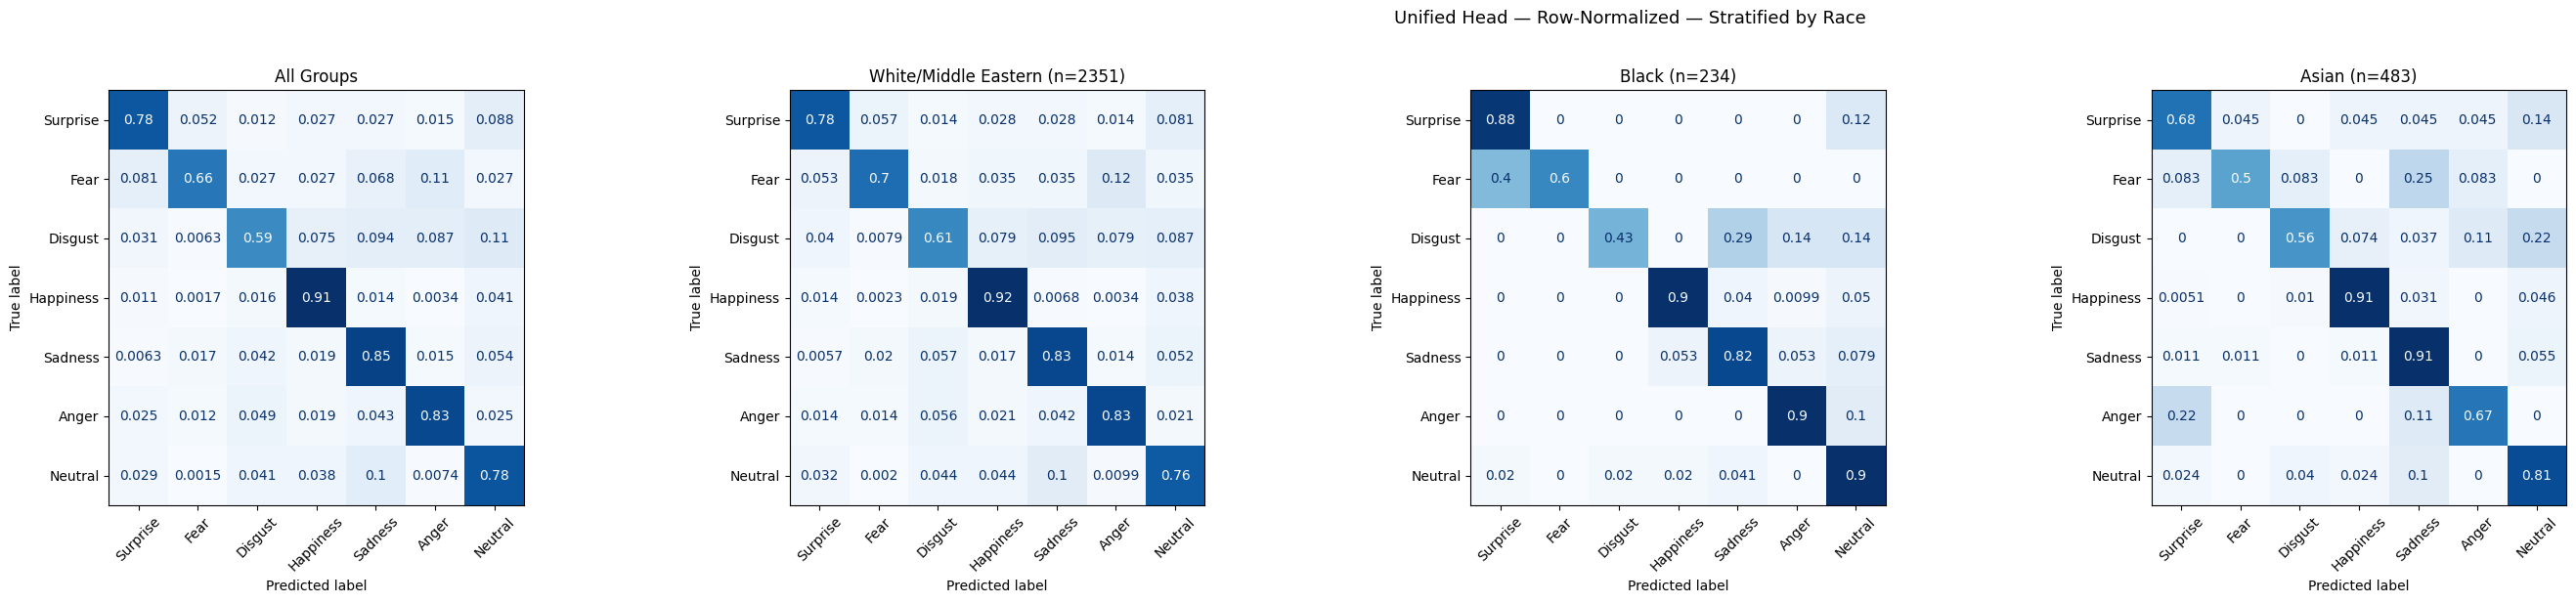

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(35, 6))  # 5 panels: 1 overall + 4 races

cm_all = confusion_matrix(all_labels, all_preds)
cm_norm = cm_all.astype('float') / cm_all.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=UNIFIED_CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("All Groups")

for i, (race_id, race_name) in enumerate(RACE_NAMES_4.items()):
    mask = all_races == race_id
    if mask.sum() == 0:
        axes[i+1].set_visible(False)
        continue
    cm = confusion_matrix(all_labels[mask], all_preds[mask],
                          labels=list(range(7)))
    cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=UNIFIED_CLASSES).plot(
        ax=axes[i+1], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[i+1].set_title(f"{race_name} (n={mask.sum()})")

plt.suptitle("Unified Head — Row-Normalized — Stratified by Race",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DEMO_CACHE}/unified_head_cm.png',
            dpi=150, bbox_inches='tight')
plt.show()

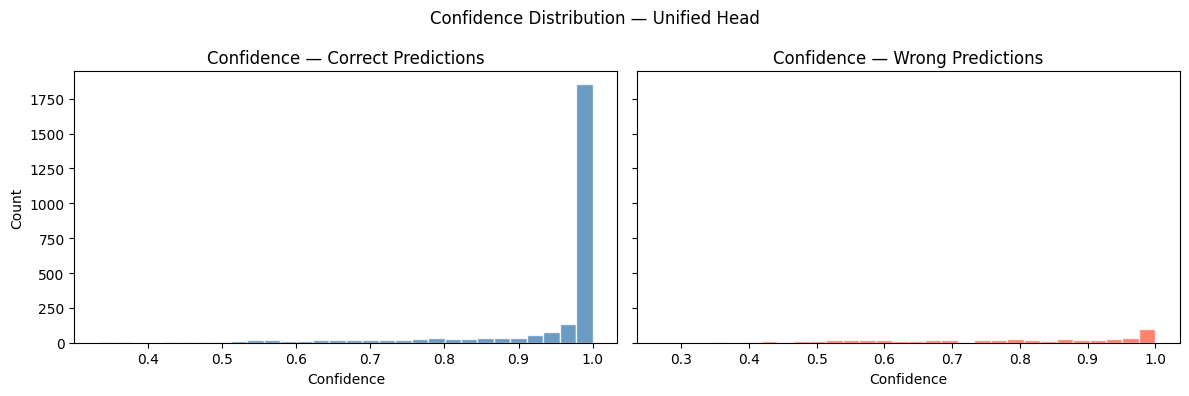


Class         Mean Conf (Correct)  Mean Conf (Wrong)  Wrong %
--------------------------------------------------------------
Surprise                    0.923              0.736    22.2%
Fear                        0.939              0.799    33.8%
Disgust                     0.901              0.779    40.6%
Happiness                   0.973              0.799     8.6%
Sadness                     0.948              0.844    15.3%
Anger                       0.941              0.766    17.3%
Neutral                     0.918              0.749    21.8%

Neutral wrong predictions — predicted as:
  Sadness: 68
  Disgust: 28
  Happiness: 26
  Surprise: 20
  Anger: 5
  Fear: 1

Neutral confidence by race:
  White/Middle Eastern      overall: 0.883 | correct: 0.926 | wrong: 0.743
  Black                     overall: 0.870 | correct: 0.881 | wrong: 0.779
  Asian                     overall: 0.880 | correct: 0.905 | wrong: 0.772


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch

UNIFIED_CLASSES = ['Surprise','Fear','Disgust', 'Happiness','Sadness','Anger','Neutral']

# all_probs, all_preds, all_labels already in memory

# Get confidence (max softmax prob) for each prediction
confidences = all_probs.max(axis=1)

# --- 1. Overall confidence distribution by correct/wrong ---

correct_mask = all_preds == all_labels
wrong_mask = ~correct_mask

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)  # <-- sharey added

axes[0].hist(confidences[correct_mask], bins=30, color='steelblue',
             alpha=0.8, edgecolor='white')
axes[0].set_title("Confidence — Correct Predictions")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")

axes[1].hist(confidences[wrong_mask], bins=30, color='tomato',
             alpha=0.8, edgecolor='white')
axes[1].set_title("Confidence — Wrong Predictions")
axes[1].set_xlabel("Confidence")

# Optionally, explicitly set the same y-limits (not strictly needed with sharey,
# but you can force it if desired):
ymin, ymax = axes[0].get_ylim()
axes[1].set_ylim(ymin, ymax)

plt.suptitle("Confidence Distribution — Unified Head", fontsize=12)
plt.tight_layout()
plt.savefig(f'{DEMO_CACHE}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Per-class confidence stats ---

print(f"\n{'Class':<12} {'Mean Conf (Correct)':>20} "
      f"{'Mean Conf (Wrong)':>18} {'Wrong %':>8}")
print("-" * 62)

for cid, cname in enumerate(UNIFIED_CLASSES):
    class_mask = all_labels == cid
    c_correct = class_mask & correct_mask
    c_wrong = class_mask & wrong_mask

    mean_c = confidences[c_correct].mean() if c_correct.sum() > 0 else 0
    mean_w = confidences[c_wrong].mean() if c_wrong.sum() > 0 else 0
    wrong_pct = c_wrong.sum() / class_mask.sum() * 100

    print(f"{cname:<12} {mean_c:>20.3f} {mean_w:>18.3f} {wrong_pct:>7.1f}%")

# --- 3. Neutral-specific: wrong predictions breakdown ---

print("\nNeutral wrong predictions — predicted as:")
neutral_mask = all_labels == 6
neutral_wrong = neutral_mask & wrong_mask
wrong_preds = all_preds[neutral_wrong]

from collections import Counter
dist = Counter(wrong_preds.tolist())
for cid, count in sorted(dist.items(), key=lambda x: -x[1]):
    print(f"  {UNIFIED_CLASSES[cid]}: {count}")

# --- 4. Per-race confidence on Neutral ---

print("\nNeutral confidence by race:")
for race_id, race_name in RACE_NAMES_4.items():
    mask = (all_races == race_id) & (all_labels == 6)
    if mask.sum() == 0:
        continue

    mean_conf = confidences[mask].mean()
    correct_conf = confidences[mask & correct_mask].mean() \
        if (mask & correct_mask).sum() > 0 else 0
    wrong_conf = confidences[mask & wrong_mask].mean() \
        if (mask & wrong_mask).sum() > 0 else 0

    print(f"  {race_name:<25} overall: {mean_conf:.3f} | "
          f"correct: {correct_conf:.3f} | wrong: {wrong_conf:.3f}")

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from collections import Counter
import numpy as np

UNIFIED_CLASSES = ['Surprise','Fear','Disgust',
                   'Happiness','Sadness','Anger','Neutral']

train_loader = DataLoader(
    TensorDataset(
        unified_train['features'], unified_train['labels'],
        unified_train['races'],    unified_train['genders'],
        unified_train['ages']
    ),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(
        test_raf['features'], test_raf['labels'],
        test_raf['races'],    test_raf['genders'],
        test_raf['ages']
    ),
    batch_size=256, shuffle=False
)

counts  = Counter(unified_train['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor(
    [total_n/counts[i] for i in range(7)], dtype=torch.float
).cuda()
weights = weights / weights.sum()
criterion_emotion = nn.CrossEntropyLoss(weight=weights)
criterion_demo    = nn.CrossEntropyLoss()

# --- Staged head ---
class StagedEmotionHead(nn.Module):
    def __init__(self, feature_dim=768,
                 num_races=4, num_genders=2, num_ages=3,
                 embed_dim=32, hidden_dim=512,
                 num_emotions=7, dropout=0.3):
        super().__init__()

        # Stage 1: demographic embeddings
        self.race_emb   = nn.Embedding(num_races,   embed_dim)
        self.gender_emb = nn.Embedding(num_genders, embed_dim)
        self.age_emb    = nn.Embedding(num_ages,    embed_dim)

        # Auxiliary demographic prediction heads (used only in Stage 1)
        self.race_aux   = nn.Linear(embed_dim, num_races)
        self.gender_aux = nn.Linear(embed_dim, num_genders)
        self.age_aux    = nn.Linear(embed_dim, num_ages)

        # Stage 2: emotion classifier
        combined_dim = feature_dim + embed_dim * 3
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_emotions)
        )

    def forward(self, feats, races, genders, ages):
        r_emb = self.race_emb(races)
        g_emb = self.gender_emb(genders)
        a_emb = self.age_emb(ages)
        combined = torch.cat([feats, r_emb, g_emb, a_emb], dim=-1)
        return self.classifier(combined)

    def forward_demo(self, races, genders, ages):
        # Used in Stage 1 only — predict demographics from embeddings
        r_emb = self.race_emb(races)
        g_emb = self.gender_emb(genders)
        a_emb = self.age_emb(ages)
        return (self.race_aux(r_emb),
                self.gender_aux(g_emb),
                self.age_aux(a_emb))


staged_head = StagedEmotionHead().cuda()

# ================================================================
# STAGE 1: Train demographic embeddings only
# Freeze classifier + aux heads not involved
# Only race_emb, gender_emb, age_emb + aux heads are updated
# ================================================================
print("="*50)
print("STAGE 1: Training demographic embeddings")
print("="*50)

# Freeze classifier
for param in staged_head.classifier.parameters():
    param.requires_grad = False

stage1_params = (
    list(staged_head.race_emb.parameters()) +
    list(staged_head.gender_emb.parameters()) +
    list(staged_head.age_emb.parameters()) +
    list(staged_head.race_aux.parameters()) +
    list(staged_head.gender_aux.parameters()) +
    list(staged_head.age_aux.parameters())
)
opt1 = optim.AdamW(stage1_params, lr=1e-3, weight_decay=0.05)

for epoch in range(15):
    staged_head.train()
    total_loss, total = 0, 0
    for feats, labels, races, genders, ages in train_loader:
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        r_logits, g_logits, a_logits = staged_head.forward_demo(
            races, genders, ages)
        loss = (criterion_demo(r_logits, races) +
                criterion_demo(g_logits, genders) +
                criterion_demo(a_logits, ages))
        opt1.zero_grad(); loss.backward(); opt1.step()
        total_loss += loss.item()
        total      += feats.size(0)
    print(f"  Epoch {epoch+1:02d}/15 | Loss: {total_loss/len(train_loader):.4f}")

# ================================================================
# STAGE 2: Freeze embeddings, train classifier only
# ================================================================
print("\n" + "="*50)
print("STAGE 2: Training emotion classifier")
print("="*50)

# Freeze embeddings + aux heads
for param in staged_head.race_emb.parameters():   param.requires_grad = False
for param in staged_head.gender_emb.parameters(): param.requires_grad = False
for param in staged_head.age_emb.parameters():    param.requires_grad = False
for param in staged_head.race_aux.parameters():   param.requires_grad = False
for param in staged_head.gender_aux.parameters(): param.requires_grad = False
for param in staged_head.age_aux.parameters():    param.requires_grad = False

# Unfreeze classifier
for param in staged_head.classifier.parameters(): param.requires_grad = True

opt2 = optim.AdamW(staged_head.classifier.parameters(),
                   lr=1e-3, weight_decay=0.05)

for epoch in range(40):
    staged_head.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt2.zero_grad(); loss.backward(); opt2.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"  Epoch {epoch+1:02d}/40 | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {correct/total:.3f} | "
          f"Val: {val_correct/val_total:.3f}")

# ================================================================
# STAGE 3: Fine-tune everything jointly at low LR
# ================================================================
print("\n" + "="*50)
print("STAGE 3: Joint fine-tuning")
print("="*50)

for param in staged_head.parameters():
    param.requires_grad = True

opt3 = optim.AdamW(staged_head.parameters(),
                   lr=1e-4, weight_decay=0.05)  # lower LR

for epoch in range(20):
    staged_head.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt3.zero_grad(); loss.backward(); opt3.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"  Epoch {epoch+1:02d}/20 | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {correct/total:.3f} | "
          f"Val: {val_correct/val_total:.3f}")

# ================================================================
# FINAL EVALUATION
# ================================================================
print("\n" + "="*50)
print("FINAL EVALUATION — Staged Head")
print("="*50)

staged_head.eval()
all_preds, all_labels, all_races, all_probs = [], [], [], []

with torch.no_grad():
    for feats, labels, races, genders, ages in test_loader:
        feats = feats.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head(feats, races, genders, ages)
        probs  = torch.softmax(logits, dim=1).cpu()
        all_probs.extend(probs.tolist())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_races.extend(races.cpu().tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_races  = np.array(all_races)

y_bin = label_binarize(all_labels, classes=list(range(7)))

print(f"\n{'Class':<12} {'Recall':>8} {'AUC':>8}")
print("-" * 30)
for cid, cname in enumerate(UNIFIED_CLASSES):
    true_c = (all_labels == cid)
    pred_c = (all_preds == cid)
    recall = (true_c & pred_c).sum() / true_c.sum()
    auc    = roc_auc_score(y_bin[:, cid], all_probs[:, cid])
    print(f"{cname:<12} {recall:>8.3f} {auc:>8.3f}")

overall_acc = (all_preds == all_labels).mean()
macro_auc   = roc_auc_score(y_bin, all_probs,
                             multi_class='ovr', average='macro')
print("-" * 30)
print(f"{'Overall':<12} {overall_acc:>8.3f} {macro_auc:>8.3f}")

print(f"\nNeutral recall per group:")
neutral_id = 6
for race_id, race_name in RACE_NAMES_4.items():
    mask = all_races == race_id
    if mask.sum() == 0: continue
    true_n = (all_labels[mask] == neutral_id)
    pred_n = (all_preds[mask]  == neutral_id)
    if true_n.sum() == 0: continue
    print(f"  {race_name}: {(true_n & pred_n).sum()/true_n.sum():.3f}")

torch.save(staged_head.state_dict(),
           f'{DEMO_CACHE}/staged_emotion_head.pt')
print("\nStaged head saved.")

STAGE 1: Training demographic embeddings
  Epoch 01/15 | Loss: 1.4041
  Epoch 02/15 | Loss: 0.2697
  Epoch 03/15 | Loss: 0.1070
  Epoch 04/15 | Loss: 0.0586
  Epoch 05/15 | Loss: 0.0377
  Epoch 06/15 | Loss: 0.0265
  Epoch 07/15 | Loss: 0.0199
  Epoch 08/15 | Loss: 0.0155
  Epoch 09/15 | Loss: 0.0125
  Epoch 10/15 | Loss: 0.0104
  Epoch 11/15 | Loss: 0.0087
  Epoch 12/15 | Loss: 0.0075
  Epoch 13/15 | Loss: 0.0065
  Epoch 14/15 | Loss: 0.0057
  Epoch 15/15 | Loss: 0.0050

STAGE 2: Training emotion classifier
  Epoch 01/40 | Loss: 1.1255 | Train: 0.588 | Val: 0.783
  Epoch 02/40 | Loss: 0.7982 | Train: 0.710 | Val: 0.780
  Epoch 03/40 | Loss: 0.6844 | Train: 0.750 | Val: 0.814
  Epoch 04/40 | Loss: 0.6172 | Train: 0.775 | Val: 0.840
  Epoch 05/40 | Loss: 0.5512 | Train: 0.797 | Val: 0.829
  Epoch 06/40 | Loss: 0.4917 | Train: 0.821 | Val: 0.830
  Epoch 07/40 | Loss: 0.4420 | Train: 0.839 | Val: 0.838
  Epoch 08/40 | Loss: 0.4114 | Train: 0.848 | Val: 0.836
  Epoch 09/40 | Loss: 0.3823 |

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import KFold
from collections import Counter
import numpy as np

UNIFIED_CLASSES = ['Surprise','Fear','Disgust',
                   'Happiness','Sadness','Anger','Neutral']

# Combine unified train + RAF-DB test into one full dataset for k-fold
all_features = torch.cat([unified_train['features'], test_raf['features']])
all_labels   = torch.cat([unified_train['labels'],   test_raf['labels']])
all_races    = torch.cat([unified_train['races'],     test_raf['races']])
all_genders  = torch.cat([unified_train['genders'],   test_raf['genders']])
all_ages     = torch.cat([unified_train['ages'],       test_raf['ages']])

print(f"Full dataset: {len(all_features)} samples")

full_dataset = TensorDataset(all_features, all_labels,
                              all_races, all_genders, all_ages)

# --- Staged head definition (same as before) ---
class StagedEmotionHead(nn.Module):
    def __init__(self, feature_dim=768,
                 num_races=4, num_genders=2, num_ages=3,
                 embed_dim=32, hidden_dim=512,
                 num_emotions=7, dropout=0.3):
        super().__init__()
        self.race_emb   = nn.Embedding(num_races,   embed_dim)
        self.gender_emb = nn.Embedding(num_genders, embed_dim)
        self.age_emb    = nn.Embedding(num_ages,    embed_dim)
        self.race_aux   = nn.Linear(embed_dim, num_races)
        self.gender_aux = nn.Linear(embed_dim, num_genders)
        self.age_aux    = nn.Linear(embed_dim, num_ages)
        combined_dim = feature_dim + embed_dim * 3
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_emotions)
        )

    def forward(self, feats, races, genders, ages):
        combined = torch.cat([
            feats,
            self.race_emb(races),
            self.gender_emb(genders),
            self.age_emb(ages)
        ], dim=-1)
        return self.classifier(combined)

    def forward_demo(self, races, genders, ages):
        r_emb = self.race_emb(races)
        g_emb = self.gender_emb(genders)
        a_emb = self.age_emb(ages)
        return (self.race_aux(r_emb),
                self.gender_aux(g_emb),
                self.age_aux(a_emb))


def train_staged(model, train_loader, criterion_emotion, criterion_demo):
    # Stage 1
    for param in model.classifier.parameters():
        param.requires_grad = False
    stage1_params = (
        list(model.race_emb.parameters()) +
        list(model.gender_emb.parameters()) +
        list(model.age_emb.parameters()) +
        list(model.race_aux.parameters()) +
        list(model.gender_aux.parameters()) +
        list(model.age_aux.parameters())
    )
    opt1 = optim.AdamW(stage1_params, lr=1e-3, weight_decay=0.05)
    for _ in range(15):
        model.train()
        for feats, labels, races, genders, ages in train_loader:
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            r_l, g_l, a_l = model.forward_demo(races, genders, ages)
            loss = (criterion_demo(r_l, races) +
                    criterion_demo(g_l, genders) +
                    criterion_demo(a_l, ages))
            opt1.zero_grad(); loss.backward(); opt1.step()

    # Stage 2
    for param in model.race_emb.parameters():   param.requires_grad = False
    for param in model.gender_emb.parameters(): param.requires_grad = False
    for param in model.age_emb.parameters():    param.requires_grad = False
    for param in model.race_aux.parameters():   param.requires_grad = False
    for param in model.gender_aux.parameters(): param.requires_grad = False
    for param in model.age_aux.parameters():    param.requires_grad = False
    for param in model.classifier.parameters(): param.requires_grad = True
    opt2 = optim.AdamW(model.classifier.parameters(),
                       lr=1e-3, weight_decay=0.05)
    for _ in range(40):
        model.train()
        for feats, labels, races, genders, ages in train_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            loss = criterion_emotion(
                model(feats, races, genders, ages), labels)
            opt2.zero_grad(); loss.backward(); opt2.step()

    # Stage 3
    for param in model.parameters(): param.requires_grad = True
    opt3 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
    for _ in range(20):
        model.train()
        for feats, labels, races, genders, ages in train_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            loss = criterion_emotion(
                model(feats, races, genders, ages), labels)
            opt3.zero_grad(); loss.backward(); opt3.step()


# --- K-Fold ---
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)
n_samples = len(full_dataset)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(range(n_samples))):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/{K} | Train: {len(train_idx)} | Val: {len(val_idx)}")
    print(f"{'='*50}")

    train_loader_kf = DataLoader(
        full_dataset,
        batch_size=256,
        sampler=SubsetRandomSampler(train_idx)
    )
    val_loader_kf = DataLoader(
        full_dataset,
        batch_size=256,
        sampler=SubsetRandomSampler(val_idx)
    )

    # Class weights for this fold
    fold_labels = all_labels[train_idx]
    counts  = Counter(fold_labels.tolist())
    total_n = sum(counts.values())
    w = torch.tensor(
        [total_n/counts.get(i, 1) for i in range(7)],
        dtype=torch.float
    ).cuda()
    w = w / w.sum()
    criterion_e = nn.CrossEntropyLoss(weight=w)
    criterion_d = nn.CrossEntropyLoss()

    model = StagedEmotionHead().cuda()
    train_staged(model, train_loader_kf, criterion_e, criterion_d)

    # Evaluate
    model.eval()
    all_preds, all_labels_f, all_races_f, all_probs = [], [], [], []
    with torch.no_grad():
        for feats, labels, races, genders, ages in val_loader_kf:
            feats = feats.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = model(feats, races, genders, ages)
            probs  = torch.softmax(logits, dim=1).cpu()
            all_probs.extend(probs.tolist())
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels_f.extend(labels.tolist())
            all_races_f.extend(races.cpu().tolist())

    all_probs    = np.array(all_probs)
    all_preds    = np.array(all_preds)
    all_labels_f = np.array(all_labels_f)
    all_races_f  = np.array(all_races_f)

    y_bin     = label_binarize(all_labels_f, classes=list(range(7)))
    acc       = (all_preds == all_labels_f).mean()
    macro_auc = roc_auc_score(y_bin, all_probs,
                               multi_class='ovr', average='macro')

    # Neutral recall per group
    neutral_id = 6
    neutral_recalls = {}
    for race_id, race_name in RACE_NAMES_4.items():
        mask = all_races_f == race_id
        if mask.sum() == 0: continue
        true_n = (all_labels_f[mask] == neutral_id)
        pred_n = (all_preds[mask]    == neutral_id)
        if true_n.sum() == 0: continue
        neutral_recalls[race_name] = \
            (true_n & pred_n).sum() / true_n.sum()

    fold_results.append({
        'fold': fold+1,
        'acc': acc,
        'auc': macro_auc,
        'neutral_recalls': neutral_recalls
    })

    print(f"Fold {fold+1} | Acc: {acc:.3f} | AUC: {macro_auc:.3f}")
    for gname, recall in neutral_recalls.items():
        print(f"  Neutral — {gname}: {recall:.3f}")

# --- Summary ---
print("\n" + "="*60)
print("K-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)

accs = [r['acc'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]

print(f"\nOverall Accuracy: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
print(f"Macro AUC:        {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")

print("\nNeutral recall per group (mean +/- std):")
for race_name in RACE_NAMES_4.values():
    recalls = [r['neutral_recalls'].get(race_name, 0)
               for r in fold_results
               if race_name in r['neutral_recalls']]
    if recalls:
        print(f"  {race_name}: {np.mean(recalls):.3f} +/- {np.std(recalls):.3f}")

Full dataset: 26294 samples

FOLD 1/5 | Train: 21035 | Val: 5259
Fold 1 | Acc: 0.759 | AUC: 0.954
  Neutral — White/Middle Eastern: 0.767
  Neutral — Black: 0.790
  Neutral — Asian: 0.802
  Neutral — Indian/Latino: 0.250

FOLD 2/5 | Train: 21035 | Val: 5259
Fold 2 | Acc: 0.762 | AUC: 0.957
  Neutral — White/Middle Eastern: 0.713
  Neutral — Black: 0.762
  Neutral — Asian: 0.790
  Neutral — Indian/Latino: 0.474

FOLD 3/5 | Train: 21035 | Val: 5259
Fold 3 | Acc: 0.760 | AUC: 0.956
  Neutral — White/Middle Eastern: 0.755
  Neutral — Black: 0.756
  Neutral — Asian: 0.793
  Neutral — Indian/Latino: 0.273

FOLD 4/5 | Train: 21035 | Val: 5259
Fold 4 | Acc: 0.754 | AUC: 0.955
  Neutral — White/Middle Eastern: 0.785
  Neutral — Black: 0.688
  Neutral — Asian: 0.765
  Neutral — Indian/Latino: 0.333

FOLD 5/5 | Train: 21036 | Val: 5258
Fold 5 | Acc: 0.768 | AUC: 0.957
  Neutral — White/Middle Eastern: 0.779
  Neutral — Black: 0.811
  Neutral — Asian: 0.778
  Neutral — Indian/Latino: 0.278

K-FOLD

Stage 1 Epoch 01/20 | Loss: 1.0408
Stage 1 Epoch 02/20 | Loss: 0.1992
Stage 1 Epoch 03/20 | Loss: 0.0838
Stage 1 Epoch 04/20 | Loss: 0.0466
Stage 1 Epoch 05/20 | Loss: 0.0300
Stage 1 Epoch 06/20 | Loss: 0.0212
Stage 1 Epoch 07/20 | Loss: 0.0159
Stage 1 Epoch 08/20 | Loss: 0.0124
Stage 1 Epoch 09/20 | Loss: 0.0100
Stage 1 Epoch 10/20 | Loss: 0.0083
Stage 1 Epoch 11/20 | Loss: 0.0070
Stage 1 Epoch 12/20 | Loss: 0.0060
Stage 1 Epoch 13/20 | Loss: 0.0052
Stage 1 Epoch 14/20 | Loss: 0.0045
Stage 1 Epoch 15/20 | Loss: 0.0040
Stage 1 Epoch 16/20 | Loss: 0.0036
Stage 1 Epoch 17/20 | Loss: 0.0032
Stage 1 Epoch 18/20 | Loss: 0.0029
Stage 1 Epoch 19/20 | Loss: 0.0026
Stage 1 Epoch 20/20 | Loss: 0.0024
Stage 2 Epoch 01/60 | Loss: 1.1255 | Val: 0.791
Stage 2 Epoch 02/60 | Loss: 0.7910 | Val: 0.808
Stage 2 Epoch 03/60 | Loss: 0.6838 | Val: 0.820
Stage 2 Epoch 04/60 | Loss: 0.6098 | Val: 0.808
Stage 2 Epoch 05/60 | Loss: 0.5563 | Val: 0.806
Stage 2 Epoch 06/60 | Loss: 0.5024 | Val: 0.825
Stage 2 Epoc

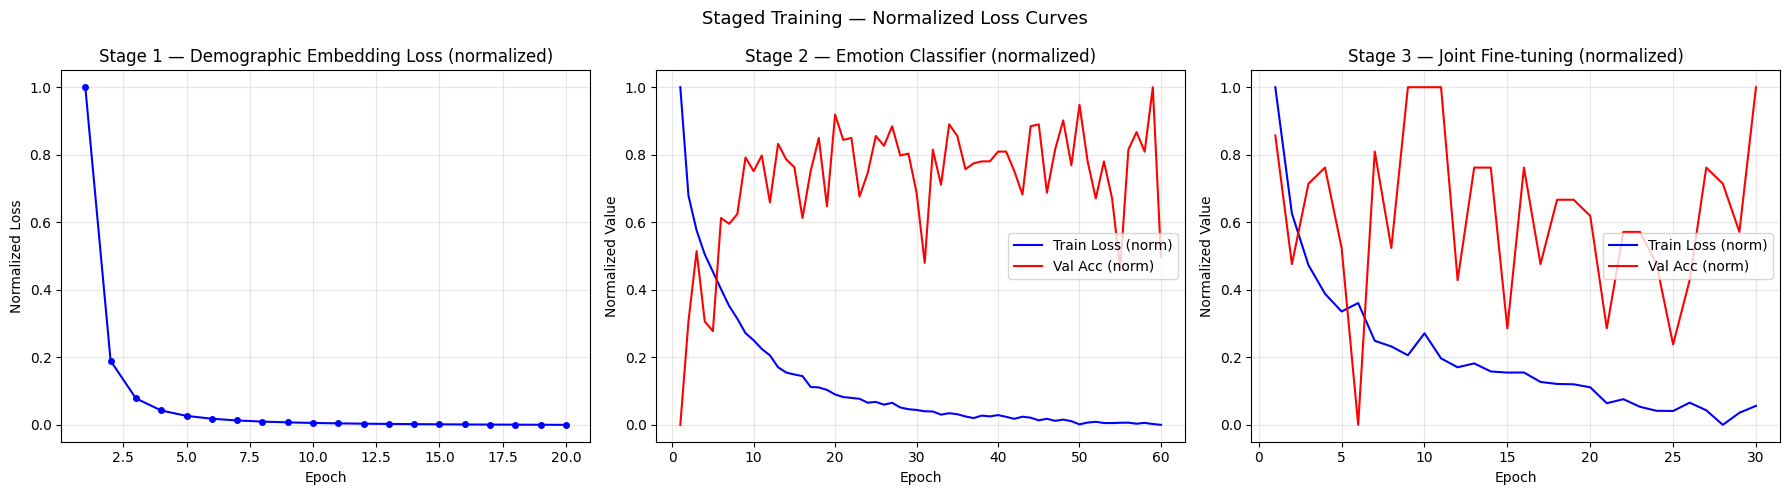

Saved.


In [44]:
import matplotlib.pyplot as plt
import numpy as np

staged_head_logged = StagedEmotionHead().cuda()

stage1_losses = []
stage2_train_losses, stage2_val_accs = [], []
stage3_train_losses, stage3_val_accs = [], []

criterion_emotion = nn.CrossEntropyLoss(weight=weights)
criterion_demo    = nn.CrossEntropyLoss()

# Stage 1 — 20 epochs
for param in staged_head_logged.classifier.parameters():
    param.requires_grad = False
stage1_params = (
    list(staged_head_logged.race_emb.parameters()) +
    list(staged_head_logged.gender_emb.parameters()) +
    list(staged_head_logged.age_emb.parameters()) +
    list(staged_head_logged.race_aux.parameters()) +
    list(staged_head_logged.gender_aux.parameters()) +
    list(staged_head_logged.age_aux.parameters())
)
opt1 = optim.AdamW(stage1_params, lr=1e-3, weight_decay=0.05)

for epoch in range(20):
    staged_head_logged.train()
    total_loss = 0
    for feats, labels, races, genders, ages in train_loader:
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        r_l, g_l, a_l = staged_head_logged.forward_demo(races, genders, ages)
        loss = (criterion_demo(r_l, races) +
                criterion_demo(g_l, genders) +
                criterion_demo(a_l, ages))
        opt1.zero_grad(); loss.backward(); opt1.step()
        total_loss += loss.item()
    stage1_losses.append(total_loss / len(train_loader))
    print(f"Stage 1 Epoch {epoch+1:02d}/20 | Loss: {stage1_losses[-1]:.4f}")

# Stage 2 — 60 epochs
for param in staged_head_logged.race_emb.parameters():   param.requires_grad = False
for param in staged_head_logged.gender_emb.parameters(): param.requires_grad = False
for param in staged_head_logged.age_emb.parameters():    param.requires_grad = False
for param in staged_head_logged.race_aux.parameters():   param.requires_grad = False
for param in staged_head_logged.gender_aux.parameters(): param.requires_grad = False
for param in staged_head_logged.age_aux.parameters():    param.requires_grad = False
for param in staged_head_logged.classifier.parameters(): param.requires_grad = True
opt2 = optim.AdamW(staged_head_logged.classifier.parameters(),
                   lr=1e-3, weight_decay=0.05)

for epoch in range(60):
    staged_head_logged.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head_logged(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt2.zero_grad(); loss.backward(); opt2.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head_logged.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head_logged(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    stage2_train_losses.append(total_loss / len(train_loader))
    stage2_val_accs.append(val_correct / val_total)
    print(f"Stage 2 Epoch {epoch+1:02d}/60 | "
          f"Loss: {stage2_train_losses[-1]:.4f} | "
          f"Val: {stage2_val_accs[-1]:.3f}")

# Stage 3 — 30 epochs
for param in staged_head_logged.parameters():
    param.requires_grad = True
opt3 = optim.AdamW(staged_head_logged.parameters(),
                   lr=1e-4, weight_decay=0.05)

for epoch in range(30):
    staged_head_logged.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head_logged(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt3.zero_grad(); loss.backward(); opt3.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head_logged.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head_logged(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    stage3_train_losses.append(total_loss / len(train_loader))
    stage3_val_accs.append(val_correct / val_total)
    print(f"Stage 3 Epoch {epoch+1:02d}/30 | "
          f"Loss: {stage3_train_losses[-1]:.4f} | "
          f"Val: {stage3_val_accs[-1]:.3f}")

# --- Plot with normalized y-axes ---
# Normalize losses to [0, 1] for comparison
def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage 1 — normalized loss
s1_norm = normalize(stage1_losses)
axes[0].plot(range(1, 21), s1_norm, 'b-o', markersize=4)
axes[0].set_title("Stage 1 — Demographic Embedding Loss (normalized)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Normalized Loss")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

# Stage 2 — normalized loss + val acc on same scale
s2_loss_norm = normalize(stage2_train_losses)
s2_acc_norm  = normalize(stage2_val_accs)
axes[1].plot(range(1, 61), s2_loss_norm, 'b-', label='Train Loss (norm)')
axes[1].plot(range(1, 61), s2_acc_norm,  'r-', label='Val Acc (norm)')
axes[1].set_title("Stage 2 — Emotion Classifier (normalized)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized Value")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc='center right')
axes[1].grid(True, alpha=0.3)

# Stage 3 — normalized loss + val acc on same scale
s3_loss_norm = normalize(stage3_train_losses)
s3_acc_norm  = normalize(stage3_val_accs)
axes[2].plot(range(1, 31), s3_loss_norm, 'b-', label='Train Loss (norm)')
axes[2].plot(range(1, 31), s3_acc_norm,  'r-', label='Val Acc (norm)')
axes[2].set_title("Stage 3 — Joint Fine-tuning (normalized)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Normalized Value")
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='center right')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Staged Training — Normalized Loss Curves", fontsize=13)
plt.tight_layout()
plt.savefig(f'{DEMO_CACHE}/staged_loss_curves_normalized.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [45]:
# Load AffectNet val cache
an_val_cache = torch.load(
    f'{DEMO_CACHE}/affectnet_val_autolabeled.pt',
    weights_only=False
)

# Get confident samples only
conf_mask = an_val_cache['confident']

# Remap AffectNet labels to RAF-DB schema
AFFECTNET_TO_RAFDB = {
    0: 5, 1: 2, 2: 2, 3: 1,
    4: 3, 5: 6, 6: 4, 7: 0,
}
an_val_labels = torch.tensor(
    [AFFECTNET_TO_RAFDB[l.item()]
     for l in an_val_cache['labels'][conf_mask]],
    dtype=torch.long
)
an_val_ages = torch.tensor(
    [AGE_TO_3CLASS[a.item()]
     for a in an_val_cache['ages'][conf_mask]],
    dtype=torch.long
)

# Build combined val set
combined_val_features = torch.cat([
    test_raf['features'],
    an_val_cache['features'][conf_mask]
])
combined_val_labels = torch.cat([
    test_raf['labels'],
    an_val_labels
])
combined_val_races = torch.cat([
    test_raf['races'],
    an_val_cache['races'][conf_mask]
])
combined_val_genders = torch.cat([
    test_raf['genders'],
    an_val_cache['genders'][conf_mask].clamp(0, 1)
])
combined_val_ages = torch.cat([
    test_raf['ages'],
    an_val_ages
])

combined_val_loader = DataLoader(
    TensorDataset(
        combined_val_features, combined_val_labels,
        combined_val_races,    combined_val_genders,
        combined_val_ages
    ),
    batch_size=256, shuffle=False
)

print(f"Combined val set: {len(combined_val_features)} samples")
print(f"  RAF-DB test: {len(test_raf['features'])}")
print(f"  AffectNet val (confident): {conf_mask.sum().item()}")

Combined val set: 6249 samples
  RAF-DB test: 3068
  AffectNet val (confident): 3181


Stage 1 Epoch 01/20 | Loss: 1.2260
Stage 1 Epoch 02/20 | Loss: 0.2286
Stage 1 Epoch 03/20 | Loss: 0.0953
Stage 1 Epoch 04/20 | Loss: 0.0529
Stage 1 Epoch 05/20 | Loss: 0.0342
Stage 1 Epoch 06/20 | Loss: 0.0241
Stage 1 Epoch 07/20 | Loss: 0.0181
Stage 1 Epoch 08/20 | Loss: 0.0141
Stage 1 Epoch 09/20 | Loss: 0.0114
Stage 1 Epoch 10/20 | Loss: 0.0094
Stage 1 Epoch 11/20 | Loss: 0.0079
Stage 1 Epoch 12/20 | Loss: 0.0068
Stage 1 Epoch 13/20 | Loss: 0.0059
Stage 1 Epoch 14/20 | Loss: 0.0052
Stage 1 Epoch 15/20 | Loss: 0.0046
Stage 1 Epoch 16/20 | Loss: 0.0041
Stage 1 Epoch 17/20 | Loss: 0.0037
Stage 1 Epoch 18/20 | Loss: 0.0033
Stage 1 Epoch 19/20 | Loss: 0.0030
Stage 1 Epoch 20/20 | Loss: 0.0027
Stage 2 Epoch 01/60 | Loss: 1.1193 | Val: 0.689
Stage 2 Epoch 02/60 | Loss: 0.7840 | Val: 0.707
Stage 2 Epoch 03/60 | Loss: 0.6794 | Val: 0.725
Stage 2 Epoch 04/60 | Loss: 0.6018 | Val: 0.735
Stage 2 Epoch 05/60 | Loss: 0.5370 | Val: 0.731
Stage 2 Epoch 06/60 | Loss: 0.4991 | Val: 0.741
Stage 2 Epoc

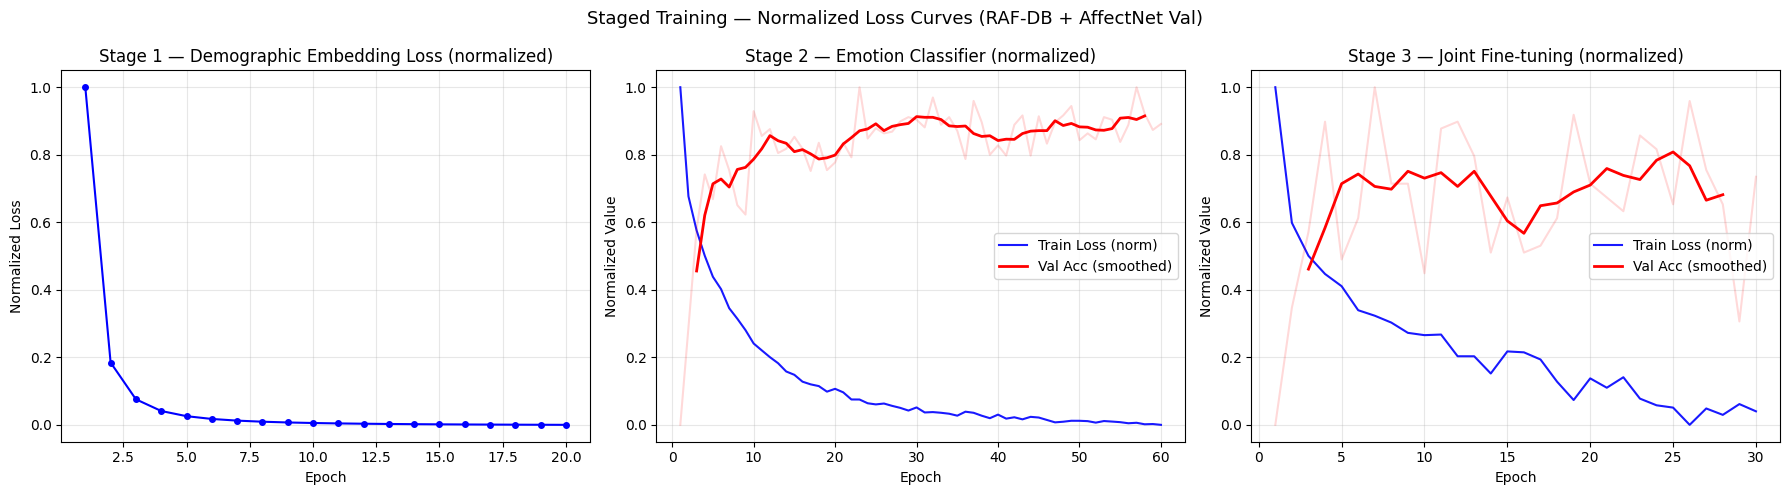

Saved.


In [46]:
import matplotlib.pyplot as plt
import numpy as np

staged_head_logged = StagedEmotionHead().cuda()

stage1_losses = []
stage2_train_losses, stage2_val_accs = [], []
stage3_train_losses, stage3_val_accs = [], []

criterion_emotion = nn.CrossEntropyLoss(weight=weights)
criterion_demo    = nn.CrossEntropyLoss()

# Stage 1 — 20 epochs
for param in staged_head_logged.classifier.parameters():
    param.requires_grad = False
stage1_params = (
    list(staged_head_logged.race_emb.parameters()) +
    list(staged_head_logged.gender_emb.parameters()) +
    list(staged_head_logged.age_emb.parameters()) +
    list(staged_head_logged.race_aux.parameters()) +
    list(staged_head_logged.gender_aux.parameters()) +
    list(staged_head_logged.age_aux.parameters())
)
opt1 = optim.AdamW(stage1_params, lr=1e-3, weight_decay=0.05)

for epoch in range(20):
    staged_head_logged.train()
    total_loss = 0
    for feats, labels, races, genders, ages in train_loader:
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        r_l, g_l, a_l = staged_head_logged.forward_demo(races, genders, ages)
        loss = (criterion_demo(r_l, races) +
                criterion_demo(g_l, genders) +
                criterion_demo(a_l, ages))
        opt1.zero_grad(); loss.backward(); opt1.step()
        total_loss += loss.item()
    stage1_losses.append(total_loss / len(train_loader))
    print(f"Stage 1 Epoch {epoch+1:02d}/20 | Loss: {stage1_losses[-1]:.4f}")

# Stage 2 — 60 epochs
for param in staged_head_logged.race_emb.parameters():   param.requires_grad = False
for param in staged_head_logged.gender_emb.parameters(): param.requires_grad = False
for param in staged_head_logged.age_emb.parameters():    param.requires_grad = False
for param in staged_head_logged.race_aux.parameters():   param.requires_grad = False
for param in staged_head_logged.gender_aux.parameters(): param.requires_grad = False
for param in staged_head_logged.age_aux.parameters():    param.requires_grad = False
for param in staged_head_logged.classifier.parameters(): param.requires_grad = True
opt2 = optim.AdamW(staged_head_logged.classifier.parameters(),
                   lr=1e-3, weight_decay=0.05)

for epoch in range(60):
    staged_head_logged.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head_logged(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt2.zero_grad(); loss.backward(); opt2.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head_logged.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in combined_val_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head_logged(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    stage2_train_losses.append(total_loss / len(train_loader))
    stage2_val_accs.append(val_correct / val_total)
    print(f"Stage 2 Epoch {epoch+1:02d}/60 | "
          f"Loss: {stage2_train_losses[-1]:.4f} | "
          f"Val: {stage2_val_accs[-1]:.3f}")

# Stage 3 — 30 epochs
for param in staged_head_logged.parameters():
    param.requires_grad = True
opt3 = optim.AdamW(staged_head_logged.parameters(),
                   lr=1e-4, weight_decay=0.05)

for epoch in range(30):
    staged_head_logged.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races, genders, ages in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
        logits = staged_head_logged(feats, races, genders, ages)
        loss   = criterion_emotion(logits, labels)
        opt3.zero_grad(); loss.backward(); opt3.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    staged_head_logged.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races, genders, ages in combined_val_loader:
            feats, labels = feats.cuda(), labels.cuda()
            races, genders, ages = races.cuda(), genders.cuda(), ages.cuda()
            logits = staged_head_logged(feats, races, genders, ages)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    stage3_train_losses.append(total_loss / len(train_loader))
    stage3_val_accs.append(val_correct / val_total)
    print(f"Stage 3 Epoch {epoch+1:02d}/30 | "
          f"Loss: {stage3_train_losses[-1]:.4f} | "
          f"Val: {stage3_val_accs[-1]:.3f}")

# --- Plot with normalized y-axes + smoothing ---
def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def smooth(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage 1
s1_norm = normalize(stage1_losses)
axes[0].plot(range(1, 21), s1_norm, 'b-o', markersize=4)
axes[0].set_title("Stage 1 — Demographic Embedding Loss (normalized)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Normalized Loss")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

# Stage 2
s2_loss_norm = normalize(stage2_train_losses)
s2_acc_norm  = normalize(stage2_val_accs)
s2_acc_smooth = smooth(s2_acc_norm, window=5)
axes[1].plot(range(1, 61), s2_loss_norm, 'b-', alpha=0.9, label='Train Loss (norm)')
axes[1].plot(range(1, 61), s2_acc_norm,  'r-', alpha=0.15)
axes[1].plot(range(3, 59), s2_acc_smooth, 'r-', linewidth=2, label='Val Acc (smoothed)')
axes[1].set_title("Stage 2 — Emotion Classifier (normalized)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized Value")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc='center right')
axes[1].grid(True, alpha=0.3)

# Stage 3
s3_loss_norm  = normalize(stage3_train_losses)
s3_acc_norm   = normalize(stage3_val_accs)
s3_acc_smooth = smooth(s3_acc_norm, window=5)
axes[2].plot(range(1, 31), s3_loss_norm, 'b-', alpha=0.9, label='Train Loss (norm)')
axes[2].plot(range(1, 31), s3_acc_norm,  'r-', alpha=0.15)
axes[2].plot(range(3, 29), s3_acc_smooth, 'r-', linewidth=2, label='Val Acc (smoothed)')
axes[2].set_title("Stage 3 — Joint Fine-tuning (normalized)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Normalized Value")
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='center right')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Staged Training — Normalized Loss Curves (RAF-DB + AffectNet Val)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{DEMO_CACHE}/staged_loss_curves_combined_val.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")